# PT Besli Manufacturing - Prediksi Risiko Kecelakaan Kerja
**REIHAN BAGAS ANANTA**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print('Library siap digunakan')

Library siap digunakan


## 1. Load Dataset

In [2]:
df = pd.read_csv('dataset_kecelakaan.csv')
print(f"Dataset memiliki {df.shape[0]} baris dan {df.shape[1]} kolom")
df.head()

Dataset memiliki 300 baris dan 9 kolom


,ID,Usia,Jam_Kerja_per_Minggu,Pengalaman_Tahun,Pelatihan_K3,Shift,Jabatan,Lokasi,Kecelakaan
0,1,58,47,10,Ya,Pagi,Supervisor,Gudang,0
1,2,48,44,17,Tidak,Siang,Supervisor,Gudang,0
2,3,34,40,22,Ya,Pagi,Manager,Gudang,0
3,4,27,37,26,Tidak,Malam,Manager,Gudang,0
4,5,40,42,25,Tidak,Pagi,Supervisor,Gudang,0


## 2. Exploratory Data Analysis (EDA)

Distribusi Target:
Kecelakaan
0    0.72
1    0.28
Name: proportion, dtype: float64


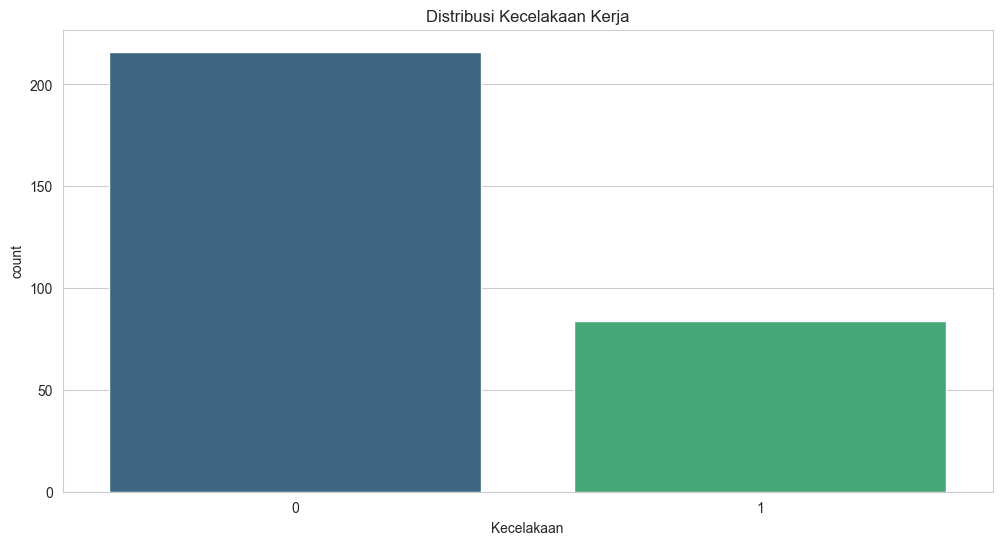

In [3]:
print("Distribusi Target:")
print(df['Kecelakaan'].value_counts(normalize=True))

sns.countplot(data=df, x='Kecelakaan', palette='viridis')
plt.title('Distribusi Kecelakaan Kerja')
plt.show()

In [4]:
# Analisis Risiko per Faktor
print("Risiko Kecelakaan per Lokasi:")
print(df.groupby('Lokasi')['Kecelakaan'].mean().sort_values(ascending=False))

print("\nRisiko per Shift:")
print(df.groupby('Shift')['Kecelakaan'].mean().sort_values(ascending=False))

print("\nRisiko Pelatihan K3:")
print(df.groupby('Pelatihan_K3')['Kecelakaan'].mean())

Risiko Kecelakaan per Lokasi:
Lokasi
Quality_Control    0.351648
Produksi           0.250000
Gudang             0.247619
Name: Kecelakaan, dtype: float64

Risiko per Shift:
Shift
Pagi     0.311927
Malam    0.273684
Siang    0.250000
Name: Kecelakaan, dtype: float64

Risiko Pelatihan K3:
Pelatihan_K3
Tidak    0.300699
Ya       0.261146
Name: Kecelakaan, dtype: float64


## 3. Preprocessing

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

X = df.drop(['ID', 'Kecelakaan'], axis=1)
y = df['Kecelakaan']

categorical_cols = ['Pelatihan_K3', 'Shift', 'Jabatan', 'Lokasi']
numerical_cols = ['Usia', 'Jam_Kerja_per_Minggu', 'Pengalaman_Tahun']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 4. Modeling & Evaluation

In [6]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Pipeline dengan SMOTE
model_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', GradientBoostingClassifier(n_estimators=150, learning_rate=0.05, 
                                             max_depth=4, random_state=42))
])

model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)
y_prob = model_pipeline.predict_proba(X_test)[:, 1]

print(" HASIL MODEL AKHIR ")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

 HASIL MODEL AKHIR 
              precision    recall  f1-score   support

           0       0.71      0.81      0.76        43
           1       0.27      0.18      0.21        17

    accuracy                           0.63        60
   macro avg       0.49      0.50      0.49        60
weighted avg       0.59      0.63      0.61        60

ROC-AUC Score: 0.5568


## 5. Feature Importance

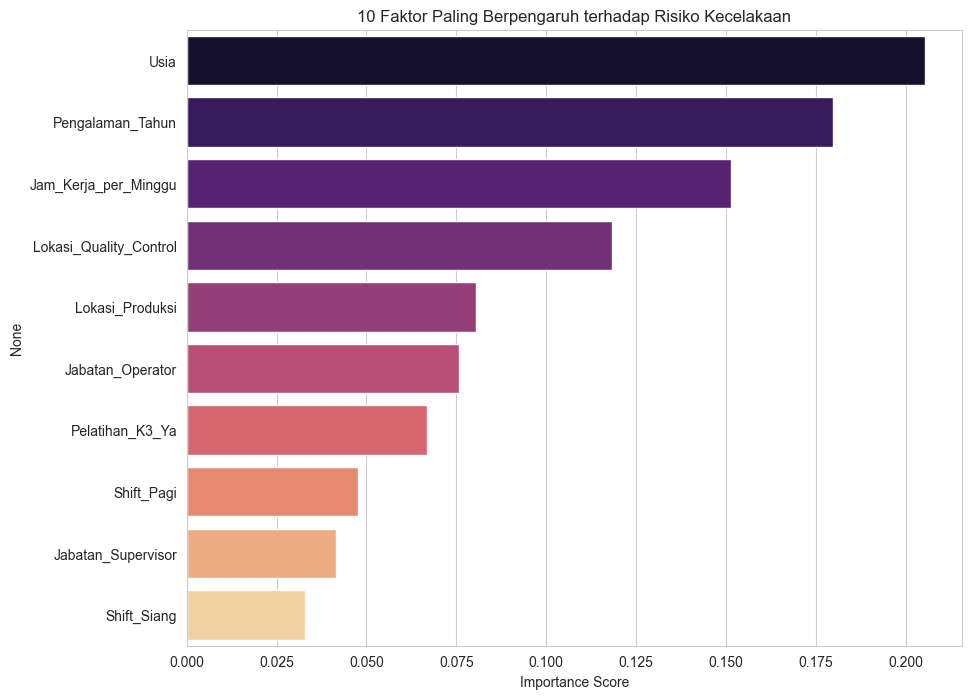

In [7]:
gb = model_pipeline.named_steps['classifier']
feature_names = numerical_cols + list(model_pipeline.named_steps['preprocessor']
                                      .named_transformers_['cat'].get_feature_names_out())

importances = pd.Series(gb.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=importances.head(10).values, y=importances.head(10).index, palette='magma')
plt.title('10 Faktor Paling Berpengaruh terhadap Risiko Kecelakaan')
plt.xlabel('Importance Score')
plt.show()

## 6. Prediksi Karyawan Baru

In [8]:
def prediksi_karyawan(data_karyawan):
    df_input = pd.DataFrame([data_karyawan])
    prob = model_pipeline.predict_proba(df_input)[0][1]
    
    print(f"Probabilitas Kecelakaan: {prob:.1%}")
    if prob >= 0.45:
        print("RISIKO TINGGI - Direkomendasikan intervensi segera")
    else:
        print(" Risiko Rendah")
    return prob

# Contoh penggunaan
contoh = {
    'Usia': 29,
    'Jam_Kerja_per_Minggu': 55,
    'Pengalaman_Tahun': 3,
    'Pelatihan_K3': 'Tidak',
    'Shift': 'Malam',
    'Jabatan': 'Operator',
    'Lokasi': 'Quality_Control'
}

prediksi_karyawan(contoh)

Probabilitas Kecelakaan: 16.0%
 Risiko Rendah


np.float64(0.16003694014002323)